<!--TITLE:Аугментация данных (Data Augmentation)-->

# Введение #

Теперь, когда вы изучили основы свёрточных классификаторов, вы готовы перейти к более продвинутым темам.

В этом уроке вы узнаете о приёме, который может значительно улучшить ваши классификаторы изображений: он называется **аугментация данных** (data augmentation).

# Полезность синтетических данных #

Лучший способ повысить производительность модели машинного обучения — обучить её на большем количестве данных. Чем больше примеров для обучения видит модель, тем лучше она сможет распознавать, какие различия в изображениях важны, а какие — нет. Больше данных помогает модели лучше *обобщать* (generalize).

Один из простых способов получить больше данных — использовать те данные, которые у вас уже есть. Если мы можем преобразовывать изображения в нашем наборе данных способами, сохраняющими принадлежность к классу, мы можем научить наш классификатор игнорировать такие преобразования. Например, повёрнут ли автомобиль на фото влево или вправо, не меняет того факта, что это *Автомобиль*, а не *Грузовик*. Таким образом, если мы **аугментируем** наши обучающие данные отражёнными изображениями, наш классификатор научится тому, что «влево или вправо» — это различие, которое следует игнорировать.

И в этом заключается вся идея аугментации данных: добавить немного дополнительных синтетических данных, которые выглядят достаточно похоже на реальные, и ваш классификатор станет лучше.

# Использование аугментации данных #

Обычно при аугментации набора данных используется множество видов преобразований. Они могут включать поворот изображения, настройку цвета или контраста, деформацию изображения и многое другое, обычно применяемое в комбинации. Вот пример различных способов преобразования одного изображения.

<figure>
<img src="./img/UaOm0ms.png" width=400, alt="Шестнадцать преобразований одного изображения автомобиля.">
</figure>

Аугментация данных обычно выполняется *онлайн*, то есть по мере подачи изображений в сеть для обучения. Напомним, что обучение обычно выполняется на мини-пакетах (mini-batches) данных. Вот как может выглядеть пакет из 16 изображений при использовании аугментации данных.

<figure>
<img src="./img/MFviYoE.png" width=400, alt="Пакет из 16 изображений с различными случайными преобразованиями.">
</figure>

Каждый раз, когда изображение используется во время обучения, применяется новое случайное преобразование. Таким образом, модель всегда видит что-то немного отличающееся от того, что она видела раньше. Эта дополнительная вариативность в обучающих данных помогает модели работать с новыми данными.

Однако важно помнить, что не каждое преобразование будет полезно для конкретной задачи. Самое главное — какие бы преобразования вы ни использовали, они не должны смешивать классы. Например, если бы вы обучали [распознаватель цифр](https://www.kaggle.com/c/digit-recognizer), поворот изображений привёл бы к путанице между '9' и '6'. В конечном счёте, лучший подход к поиску хороших аугментаций такой же, как и в большинстве задач ML: попробуйте и посмотрите!

# Пример — Обучение с аугментацией данных #

Keras позволяет аугментировать данные двумя способами. Первый способ — включить аугментацию в конвейер данных с помощью функции [`ImageDataGenerator`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator). Второй способ — включить её в определение модели, используя **слои предобработки** (preprocessing layers) Keras. Мы воспользуемся именно этим подходом. Главное преимущество для нас в том, что преобразования изображений будут вычисляться на GPU, а не на CPU, что потенциально ускоряет обучение.

В этом упражнении мы узнаем, как улучшить классификатор из Урока 1 с помощью аугментации данных. Следующая скрытая ячейка настраивает конвейер данных.

In [1]:

# Импорты
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Воспроизводимость
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    #os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Настройка Matplotlib по умолчанию
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # для очистки выходных ячеек


# Загрузка обучающего и проверочного наборов
ds_train_ = image_dataset_from_directory(
    '/tf/Lessons/4._Computer_Vision/data/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '/tf/Lessons/4._Computer_Vision/data/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Конвейер данных
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


2026-06-24 07:43:16.574770: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 07:43:16.961302: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-24 07:43:16.961364: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-24 07:43:16.974490: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-24 07:43:17.022837: I tensorflow/core/platform/cpu_feature_guar

Found 5117 files belonging to 2 classes.


2026-06-24 07:43:33.919178: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 07:43:33.993220: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 07:43:33.993312: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 07:43:33.995528: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-24 07:43:33.995565: I external/local_xla/xla/stream_executor

Found 5051 files belonging to 2 classes.


## Шаг 2 — Определение модели ##

Чтобы проиллюстрировать эффект аугментации, мы добавим лишь пару простых преобразований к модели из Урока 1.

In [3]:
from tensorflow import keras
from tensorflow.keras import layers
# это новая функция в TF 2.2
from tensorflow.keras.layers.experimental import preprocessing


pretrained_base = tf.keras.models.load_model(
    '/tf/Lessons/4._Computer_Vision/data/cv-course-models/vgg16-pretrained-base',
)
pretrained_base.trainable = False

model = keras.Sequential([
    # Предобработка
    preprocessing.RandomFlip('horizontal'), # отражение слева-направо
    preprocessing.RandomContrast(0.5), # изменение контраста до 50%
    # База
    pretrained_base,
    # Голова
    layers.Flatten(),
    layers.Dense(6, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

## Шаг 3 — Обучение и оценка ##

А теперь запустим обучение!

In [4]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=30,
    verbose=0,
)

2026-06-24 07:46:13.655718: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-06-24 07:46:16.852147: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-24 07:46:17.267156: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-24 07:46:20.227654: I external/local_xla/xla/service/service.cc:168] XLA service 0x7e9ee82fcea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-24 07:46:20.227749: I external/local_xla/xla/service/service.

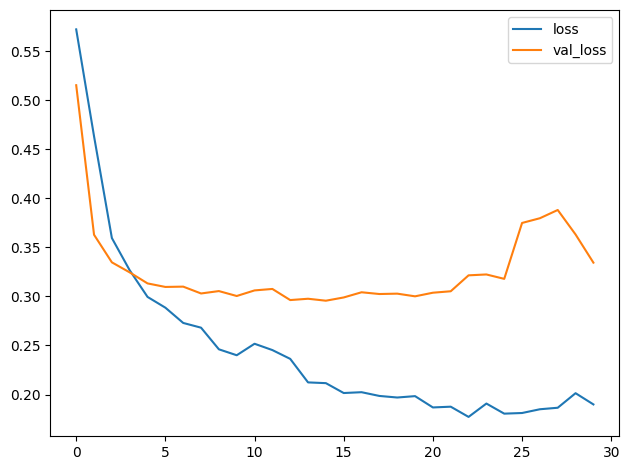

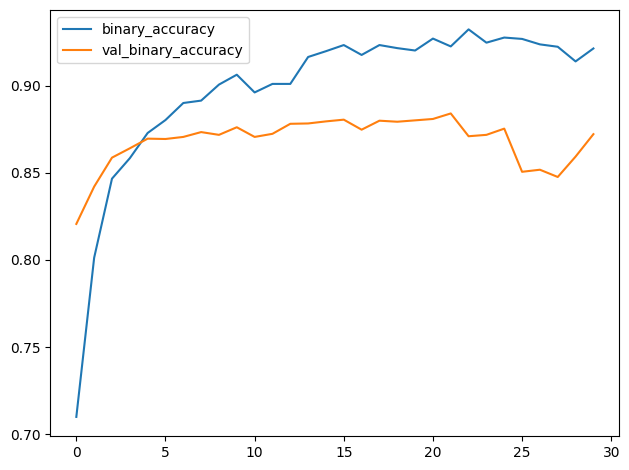

In [6]:
import pandas as pd

history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

Кривые обучения и валидации в модели из Урока 1 довольно быстро расходились, что указывало на необходимость регуляризации. Кривые обучения для этой модели смогли оставаться ближе друг к другу, и мы добились некоторого улучшения в значении функции потерь и точности на валидации. Это говорит о том, что набор данных действительно выиграл от аугментации.

# Ваша очередь #

Переходите к [**Упражнению**](https://www.kaggle.com/kernels/fork/11991328), чтобы применить аугментацию данных к собственной свёрточной сети, которую вы построили в Уроке 5. Это будет ваша лучшая модель!

---



*Остались вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*